<a href="https://colab.research.google.com/github/sarkriti/CSCE-676-Semester-Project/blob/main/DataMiningProject_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining Project - Updated for Engineered Gender Disparity Dataset

This notebook version uses `gender_disparity_dataset.csv`, which is already cleaned and engineered at the disease-county-year level. It removes the old sex-level pivoting steps and updates the anomaly detection workflow to use the new disparity-focused features.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## Load dataset

Here we are loading our dataset "gender_disparity_dataset.csv" which is the output of our dataset after applying our data preprocessing steps. You can find our data preprocessing script in the scripts folder of the repository.


In [3]:
csv_file_path = 'gender_disparity_dataset.csv'
df = pd.read_csv(csv_file_path)
print(f'Loaded engineered disparity dataset from {csv_file_path}')
print(f'Shape: {df.shape}')
display(df.head())

Loaded engineered disparity dataset from gender_disparity_dataset.csv
Shape: (65250, 21)


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population
0,Anaplasmosis,Alameda,2001,0.0,0.0,746596.0,718968.0,0.0,0.0,0.0,1465564.0,0.0,0.0,NaN,0.0,1,0,0,1,0.0,14.197751
1,Anaplasmosis,Alameda,2002,0.0,0.0,747987.0,720481.0,0.0,0.0,0.0,1468468.0,0.0,0.0,NaN,0.0,1,0,0,1,0.0,14.199731
2,Anaplasmosis,Alameda,2003,0.0,0.0,747441.0,719746.0,0.0,0.0,0.0,1467187.0,0.0,0.0,NaN,0.0,1,0,0,1,0.0,14.198858
3,Anaplasmosis,Alameda,2004,0.0,0.0,746723.0,718817.0,0.0,0.0,0.0,1465540.0,0.0,0.0,NaN,0.0,1,0,0,1,0.0,14.197735
4,Anaplasmosis,Alameda,2005,0.0,0.0,743878.0,716004.0,0.0,0.0,0.0,1459882.0,0.0,0.0,NaN,0.0,1,0,0,1,0.0,14.193867


## Select modeling subset and features

In order to observe the gender disparity for certain diseases in different counties and evaluate their risk, the features we are selecting for anamoly detection are the male rate, female rate, difference in rate (both absolute and non absolute in order to capture magnitude and direction), rate ratio, total cases, and total population per county. Since we want to observe gender disparity amongst different diseases, we drop rows where we have zero cases for both men and women.  

In [4]:
identifier_cols = ['disease', 'county', 'year']

features = [
    'male_rate',
    'female_rate',
    'rate_diff',
    'abs_rate_diff',
    'log_rate_ratio',
    'log_total_cases',
    'log_total_population',
]

df_model = df[df['both_zero_cases'] == 0].copy()
X = df_model[features].apply(pd.to_numeric, errors='coerce')
X_cleaned = X.dropna().copy()

print(f'Rows in full engineered dataset: {len(df)}')
print(f'Rows after removing both_zero_cases == 1: {len(df_model)}')
print(f'Rows after dropping NaNs in selected features: {len(X_cleaned)}')
print('Selected features:', features)
display(X_cleaned.head())

Rows in full engineered dataset: 65250
Rows after removing both_zero_cases == 1: 13495
Rows after dropping NaNs in selected features: 13495
Selected features: ['male_rate', 'female_rate', 'rate_diff', 'abs_rate_diff', 'log_rate_ratio', 'log_total_cases', 'log_total_population']


,male_rate,female_rate,rate_diff,abs_rate_diff,log_rate_ratio,log_total_cases,log_total_population
15,0.000000,0.120211,-0.120211,0.120211,-11.697010,0.693147,14.309577
16,0.122943,0.000000,0.122943,0.122943,11.719481,0.693147,14.316742
18,0.121565,0.000000,0.121565,0.121565,11.708212,0.693147,14.327715
20,0.000000,0.117469,-0.117469,0.117469,-11.673936,0.693147,14.333313
90,0.000000,0.880770,-0.880770,0.880770,-13.688553,0.693147,12.335947


# Parameter Tuning

## Tune Isolation Forest Parameters

In order to determine the parameters we will use for our anamoly detection methods, we will now perform parameter tuning to determine the n_estimators, max_samples, and contamination values for isolation forest by iterating through a list of potential values. Simialrly we will use the same method to determine the neighbor parameter we will use for both KNN and LOF.

In [5]:
param_grid_iforest = {
    'n_estimators': [100, 200, 300],
    'max_samples': [0.1, 0.25, 0.5, 'auto'],
    'contamination': [0.005, 0.01, 0.02, 0.05],
}

results_iforest_tuning = []

print('Starting Isolation Forest parameter tuning...')
for n_est, max_samp, contam in product(
    param_grid_iforest['n_estimators'],
    param_grid_iforest['max_samples'],
    param_grid_iforest['contamination'],
):
    iso_tuning = IsolationForest(
        n_estimators=n_est,
        max_samples=max_samp,
        contamination=contam,
        random_state=0,
        n_jobs=-1
    )
    preds = iso_tuning.fit_predict(X_cleaned)
    num_anomalies = np.sum(preds == -1)
    results_iforest_tuning.append({
        'n_estimators': n_est,
        'max_samples': max_samp,
        'contamination': contam,
        'num_anomalies': num_anomalies
    })

results_df_iforest = pd.DataFrame(results_iforest_tuning)
display(results_df_iforest.sort_values('num_anomalies', ascending=False).head(10))

Starting Isolation Forest parameter tuning...


,n_estimators,max_samples,contamination,num_anomalies
3,100,0.1,0.05,675
7,100,0.25,0.05,675
15,100,auto,0.05,675
11,100,0.5,0.05,675
27,200,0.5,0.05,675
31,200,auto,0.05,675
23,200,0.25,0.05,675
19,200,0.1,0.05,675
35,300,0.1,0.05,675
39,300,0.25,0.05,675


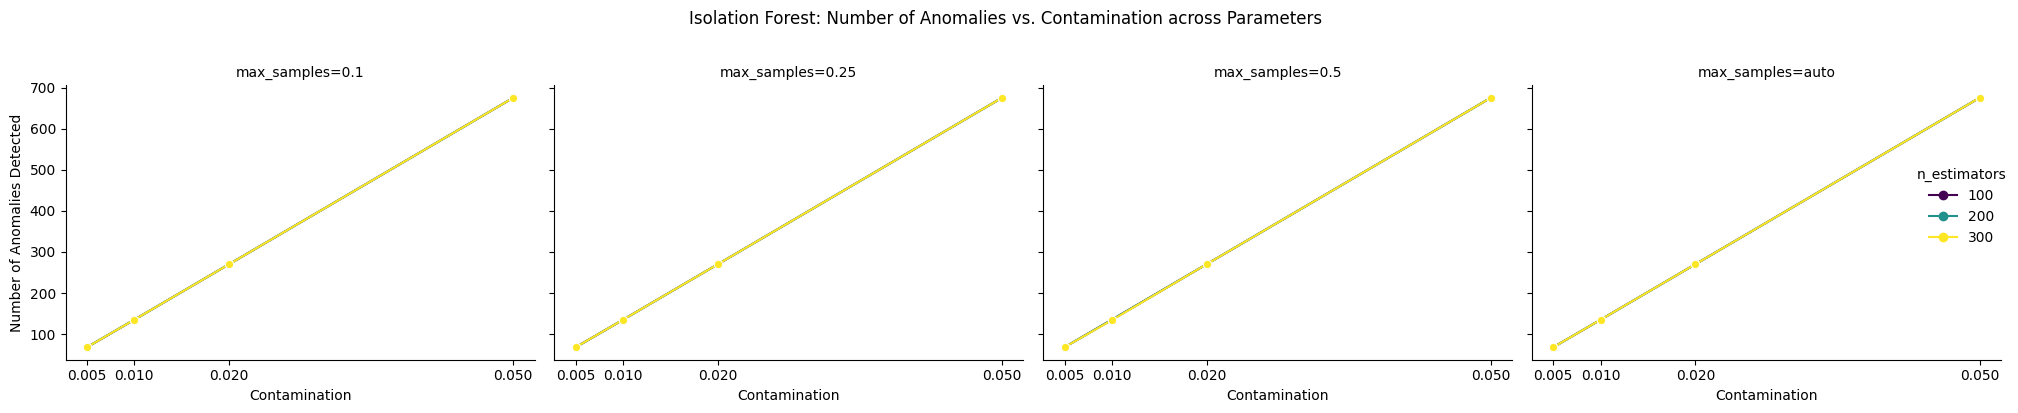

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert max_samples to string if it's 'auto' for consistent plotting
results_df_iforest['max_samples_str'] = results_df_iforest['max_samples'].astype(str)

g = sns.relplot(
    data=results_df_iforest,
    x='contamination',
    y='num_anomalies',
    hue='n_estimators',
    col='max_samples_str',
    kind='line',
    marker='o',
    height=4, aspect=1.2,
    palette='viridis'
)
g.set_axis_labels('Contamination', 'Number of Anomalies Detected')
g.set_titles("max_samples={col_name}")
g.fig.suptitle('Isolation Forest: Number of Anomalies vs. Contamination across Parameters', y=1.02)
g.set(xticks=results_df_iforest['contamination'].unique()) # Set specific x-ticks
plt.tight_layout()
plt.show()

In [7]:
print(results_df_iforest[results_df_iforest['max_samples'] == 0.1].head(4))
display(results_df_iforest[results_df_iforest['max_samples'] == 0.25].head(4))

print('max_samples = 0.25:')
display(results_df_iforest[results_df_iforest['max_samples'] == 0.25].head(4))

print('\nmax_samples = 0.5:')
display(results_df_iforest[results_df_iforest['max_samples'] == 0.5].head(4))

print('\nmax_samples = auto:')
display(results_df_iforest[results_df_iforest['max_samples'] == 'auto'].head(4))

   n_estimators max_samples  contamination  num_anomalies max_samples_str
0           100         0.1          0.005             68             0.1
1           100         0.1          0.010            135             0.1
2           100         0.1          0.020            270             0.1
3           100         0.1          0.050            675             0.1


,n_estimators,max_samples,contamination,num_anomalies,max_samples_str
4,100,0.25,0.005,68,0.25
5,100,0.25,0.010,135,0.25
6,100,0.25,0.020,270,0.25
7,100,0.25,0.050,675,0.25


max_samples = 0.25:


,n_estimators,max_samples,contamination,num_anomalies,max_samples_str
4,100,0.25,0.005,68,0.25
5,100,0.25,0.010,135,0.25
6,100,0.25,0.020,270,0.25
7,100,0.25,0.050,675,0.25



max_samples = 0.5:


,n_estimators,max_samples,contamination,num_anomalies,max_samples_str
8,100,0.5,0.005,68,0.5
9,100,0.5,0.010,135,0.5
10,100,0.5,0.020,270,0.5
11,100,0.5,0.050,675,0.5



max_samples = auto:


,n_estimators,max_samples,contamination,num_anomalies,max_samples_str
12,100,auto,0.005,68,auto
13,100,auto,0.010,135,auto
14,100,auto,0.020,270,auto
15,100,auto,0.050,675,auto


## Tune n_neighbors parameters for LOF

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


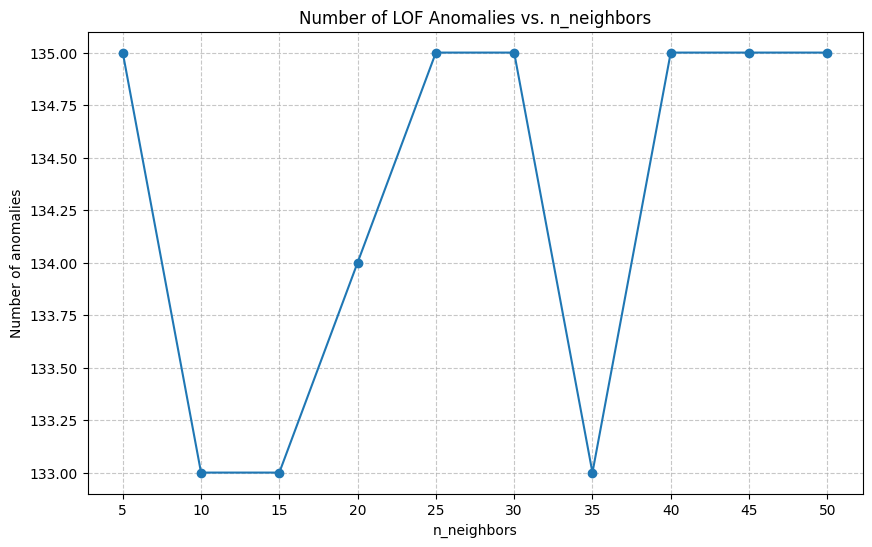

In [8]:
n_neighbors_values_lof = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
results_lof = {}
contamination_lof = 0.01

for n_neighbors_lof in n_neighbors_values_lof:
    lof_tuning = LocalOutlierFactor(
        n_neighbors=n_neighbors_lof,
        contamination=contamination_lof,
        novelty=False
    )
    preds = lof_tuning.fit_predict(X_cleaned)
    results_lof[n_neighbors_lof] = np.sum(preds == -1)

plt.figure(figsize=(10, 6))
plt.plot(list(results_lof.keys()), list(results_lof.values()), marker='o')
plt.title('Number of LOF Anomalies vs. n_neighbors')
plt.xlabel('n_neighbors')
plt.ylabel('Number of anomalies')
plt.xticks(n_neighbors_values_lof)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Tune n_neighbors parameters for KNN

Starting KNN parameter tuning...


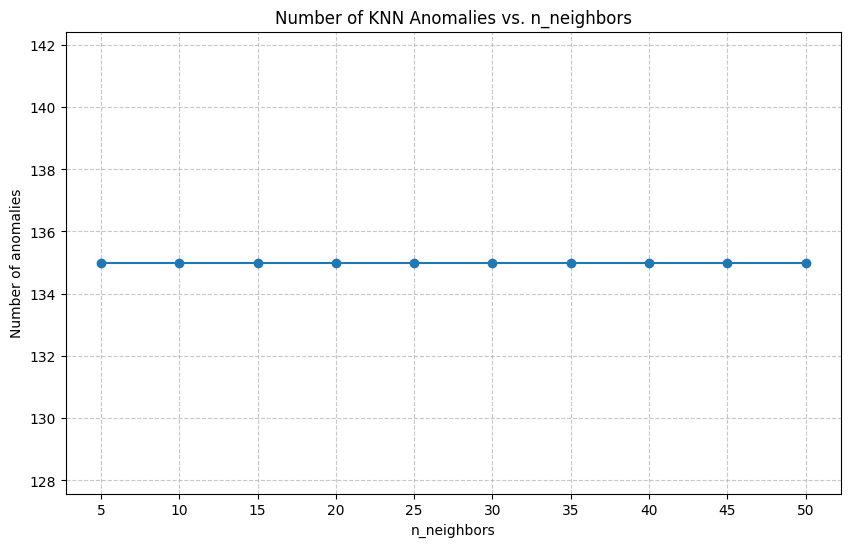

In [9]:
n_neighbors_values_knn = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
results_knn = {}
contamination_knn_tuning = 0.01

print('Starting KNN parameter tuning...')
for n_neighbors_knn_tuning in n_neighbors_values_knn:
    nbrs_tuning = NearestNeighbors(n_neighbors=n_neighbors_knn_tuning)
    nbrs_tuning.fit(X_cleaned)
    distances_tuning, _ = nbrs_tuning.kneighbors(X_cleaned)

    anomaly_scores_knn_tuning = distances_tuning.mean(axis=1)
    threshold_score_knn_tuning = np.percentile(anomaly_scores_knn_tuning, 100 - contamination_knn_tuning * 100)
    anomaly_predictions_knn_tuning = np.where(anomaly_scores_knn_tuning >= threshold_score_knn_tuning, -1, 1)
    results_knn[n_neighbors_knn_tuning] = np.sum(anomaly_predictions_knn_tuning == -1)

plt.figure(figsize=(10, 6))
plt.plot(list(results_knn.keys()), list(results_knn.values()), marker='o')
plt.title('Number of KNN Anomalies vs. n_neighbors')
plt.xlabel('n_neighbors')
plt.ylabel('Number of anomalies')
plt.xticks(n_neighbors_values_knn)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

After observing the variance in anamolies detected with different parameters, I have decided to choose the following parameters for our isolation forest model:


*   Contamination: 0.010
*   n_estimator: 200


For KNN and LOF:
* n_neighbors: 20



#Anamoly Detection Application

## Isolation Forest



In [10]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=0
)

anomaly_predictions = iso.fit_predict(X_cleaned)

df_model['anomaly_iforest'] = 0
df_model.loc[X_cleaned.index, 'anomaly_iforest'] = anomaly_predictions

df_model['anomaly_score_iforest'] = np.nan
df_model.loc[X_cleaned.index, 'anomaly_score_iforest'] = -iso.score_samples(X_cleaned)

print(f'Number of rows processed by IsolationForest: {len(X_cleaned)}')
print(f'Number of anomalies detected: {np.sum(df_model['anomaly_iforest'] == -1)}')
display(df_model[df_model['anomaly_iforest'] == -1].head())

Number of rows processed by IsolationForest: 13495
Number of anomalies detected: 135


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest
9728,Campylobacteriosis,Lake,2023,20.0,13.0,32037.0,32086.0,62.428,40.516,33.0,64123.0,-21.912,21.912,0.649004,-0.432317,0,0,0,0,3.526361,11.068574,-1,0.693116
9775,Campylobacteriosis,Madera,2001,19.0,31.0,65826.0,60630.0,28.864,51.130,50.0,126456.0,22.266,22.266,1.771411,0.571776,0,0,0,0,3.931826,11.747658,-1,0.668255
9862,Campylobacteriosis,Mendocino,2019,20.0,26.0,43848.0,44277.0,45.612,58.721,46.0,88125.0,13.109,13.109,1.287402,0.252627,0,0,0,0,3.850148,11.386523,-1,0.665546
9863,Campylobacteriosis,Mendocino,2020,36.0,15.0,43579.0,43912.0,82.609,34.159,51.0,87491.0,-48.450,48.450,0.413502,-0.883093,0,0,0,0,3.951244,11.379303,-1,0.723674
9866,Campylobacteriosis,Mendocino,2023,36.0,24.0,44134.0,44329.0,81.570,54.141,60.0,88463.0,-27.429,27.429,0.663737,-0.409870,0,0,0,0,4.110874,11.390351,-1,0.726617


## Local Outlier Factor


In [11]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01,
    novelty=False
)

anomaly_predictions_lof = lof.fit_predict(X_cleaned)

df_model['anomaly_lof'] = 0
df_model.loc[X_cleaned.index, 'anomaly_lof'] = anomaly_predictions_lof

print(f'Number of rows processed by LOF: {len(X_cleaned)}')
print(f'Number of anomalies detected by LOF: {np.sum(df_model['anomaly_lof'] == -1)}')
display(df_model[df_model['anomaly_lof'] == -1].head())

Number of rows processed by LOF: 13495
Number of anomalies detected by LOF: 134


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof
7424,"Botulism, Wound",Riverside,2019,0.0,2.0,1218203.0,1210261.0,0.000,0.165254,2.0,2428464.0,0.165254,0.165254,NaN,12.015243,0,1,0,1,1.098612,14.702770,1,0.418006,-1
7425,"Botulism, Wound",Riverside,2020,0.0,2.0,1229099.0,1220200.0,0.000,0.163908,2.0,2449299.0,0.163908,0.163908,NaN,12.007064,0,1,0,1,1.098612,14.711313,1,0.418006,-1
9171,Brucellosis,Sutter,2018,0.0,1.0,50535.0,50324.0,0.000,1.987123,1.0,100859.0,1.987123,1.987123,NaN,14.502199,0,1,0,1,0.693147,11.521489,1,0.525942,-1
9728,Campylobacteriosis,Lake,2023,20.0,13.0,32037.0,32086.0,62.428,40.516000,33.0,64123.0,-21.912000,21.912000,0.649004,-0.432317,0,0,0,0,3.526361,11.068574,-1,0.693116,-1
9863,Campylobacteriosis,Mendocino,2020,36.0,15.0,43579.0,43912.0,82.609,34.159000,51.0,87491.0,-48.450000,48.450000,0.413502,-0.883093,0,0,0,0,3.951244,11.379303,-1,0.723674,-1


## KNN-style anomaly detection

In [12]:
n_neighbors_knn = 20
nbrs = NearestNeighbors(n_neighbors=n_neighbors_knn)
nbrs.fit(X_cleaned)
distances, indices = nbrs.kneighbors(X_cleaned)

anomaly_scores_knn = distances.mean(axis=1)
contamination_knn = 0.01
threshold_score = np.percentile(anomaly_scores_knn, 100 - contamination_knn * 100)
anomaly_predictions_knn = np.where(anomaly_scores_knn >= threshold_score, -1, 1)

df_model['anomaly_knn'] = 0
df_model.loc[X_cleaned.index, 'anomaly_knn'] = anomaly_predictions_knn
df_model['anomaly_score_knn'] = np.nan
df_model.loc[X_cleaned.index, 'anomaly_score_knn'] = anomaly_scores_knn

print(f'Number of rows processed by KNN-style detector: {len(X_cleaned)}')
print(f'Number of anomalies detected by KNN-style detector: {np.sum(df_model['anomaly_knn'] == -1)}')
display(df_model[df_model['anomaly_knn'] == -1].head())

Number of rows processed by KNN-style detector: 13495
Number of anomalies detected by KNN-style detector: 135


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof,anomaly_knn,anomaly_score_knn
9424,Campylobacteriosis,Butte,2018,53.0,41.0,113297.0,113143.0,46.780,36.237,94.0,226440.0,-10.543,10.543,0.774626,-0.255375,0,0,0,0,4.553877,12.330240,1,0.621203,1,-1,9.487965
9429,Campylobacteriosis,Butte,2023,51.0,34.0,113880.0,114743.0,44.784,29.631,85.0,228623.0,-15.153,15.153,0.661643,-0.413030,0,0,0,0,4.454347,12.339834,1,0.635124,1,-1,12.038672
9632,Campylobacteriosis,Imperial,2019,45.0,38.0,93001.0,95961.0,48.387,39.599,83.0,188962.0,-8.788,8.788,0.818381,-0.200427,0,0,0,0,4.430817,12.149307,1,0.625829,1,-1,9.923180
9633,Campylobacteriosis,Imperial,2020,46.0,44.0,92594.0,95496.0,49.679,46.075,90.0,188090.0,-3.604,3.604,0.927454,-0.075312,0,0,0,0,4.510860,12.144681,1,0.605877,1,-1,8.261848
9635,Campylobacteriosis,Imperial,2022,61.0,63.0,94987.0,97973.0,64.219,64.303,124.0,192960.0,0.084,0.084,1.001308,0.001307,0,0,0,0,4.828314,12.170243,1,0.624721,1,-1,19.520266


**Summary**

Isolation Forest: 135 detected anamolies

LOF: 134 detected anamolies

KNN: 135 detected anamolies

# Detected Anamoly Comparison

**Question: What diseases are represented within our detected anomalous points for each method?**

## Top Isolation Forest anomalies

Sort flagged rows by anomaly score to inspect the most unusual male/female disparity patterns first.

In [13]:
df_model['anomaly_both_if_lof'] = ((df_model['anomaly_iforest'] == -1) & (df_model['anomaly_lof'] == -1)).astype(int)
df_model['anomaly_both_if_knn'] = ((df_model['anomaly_iforest'] == -1) & (df_model['anomaly_knn'] == -1)).astype(int)
df_model['anomaly_both_lof_knn'] = ((df_model['anomaly_lof'] == -1) & (df_model['anomaly_knn'] == -1)).astype(int)
df_model['anomaly_all_three'] = ((df_model['anomaly_iforest'] == -1) & (df_model['anomaly_lof'] == -1) & (df_model['anomaly_knn'] == -1)).astype(int)

df_model['anomaly_iforest_only'] = ((df_model['anomaly_iforest'] == -1) & (df_model['anomaly_lof'] != -1) & (df_model['anomaly_knn'] != -1)).astype(int)
df_model['anomaly_lof_only'] = ((df_model['anomaly_lof'] == -1) & (df_model['anomaly_iforest'] != -1) & (df_model['anomaly_knn'] != -1)).astype(int)
df_model['anomaly_knn_only'] = ((df_model['anomaly_knn'] == -1) & (df_model['anomaly_iforest'] != -1) & (df_model['anomaly_lof'] != -1)).astype(int)

print(f"Total anomalies detected by Isolation Forest: {np.sum(df_model['anomaly_iforest'] == -1)}")
print(f"Total anomalies detected by LOF: {np.sum(df_model['anomaly_lof'] == -1)}")
print(f"Total anomalies detected by KNN: {np.sum(df_model['anomaly_knn'] == -1)}")
print(f"Anomalies detected by BOTH IF and LOF: {df_model['anomaly_both_if_lof'].sum()}")
print(f"Anomalies detected by BOTH IF and KNN: {df_model['anomaly_both_if_knn'].sum()}")
print(f"Anomalies detected by BOTH LOF and KNN: {df_model['anomaly_both_lof_knn'].sum()}")
print(f"Anomalies detected by ALL THREE methods: {df_model['anomaly_all_three'].sum()}")

Total anomalies detected by Isolation Forest: 135
Total anomalies detected by LOF: 134
Total anomalies detected by KNN: 135
Anomalies detected by BOTH IF and LOF: 7
Anomalies detected by BOTH IF and KNN: 115
Anomalies detected by BOTH LOF and KNN: 9
Anomalies detected by ALL THREE methods: 7


In [14]:
def get_top_diseases_df(df, anomaly_col, method_name, top_n=3):
    if anomaly_col in ['anomaly_both_if_lof', 'anomaly_both_if_knn', 'anomaly_both_lof_knn', 'anomaly_all_three']:
        anomalies = df[df[anomaly_col] == 1]
    else:
        anomalies = df[df[anomaly_col] == -1]

    if not anomalies.empty:
        top_diseases = anomalies['disease'].value_counts().head(top_n).reset_index()
        top_diseases.columns = ['Disease', 'Count']
        top_diseases['Method'] = method_name
        return top_diseases
    else:
        return pd.DataFrame(columns=['Disease', 'Count', 'Method'])


all_top_diseases = pd.concat([
    get_top_diseases_df(df_model, 'anomaly_iforest', 'Isolation Forest'),
    get_top_diseases_df(df_model, 'anomaly_lof', 'LOF'),
    get_top_diseases_df(df_model, 'anomaly_knn', 'KNN'),
    get_top_diseases_df(df_model, 'anomaly_both_if_lof', 'IF & LOF Overlap'),
    get_top_diseases_df(df_model, 'anomaly_both_if_knn', 'IF & KNN Overlap'),
    get_top_diseases_df(df_model, 'anomaly_both_lof_knn', 'LOF & KNN Overlap'),
    get_top_diseases_df(df_model, 'anomaly_all_three', 'All Three Overlap'),
])

display(all_top_diseases)

,Disease,Count,Method
0,Coccidioidomycosis,96,Isolation Forest
1,Campylobacteriosis,21,Isolation Forest
2,Giardiasis,9,Isolation Forest
0,Shiga toxin-producing E. coli (STEC) without HUS,11,LOF
1,Cryptosporidiosis,10,LOF
2,Hemolytic Uremic Syndrome,10,LOF
0,Coccidioidomycosis,89,KNN
1,Campylobacteriosis,30,KNN
2,Giardiasis,6,KNN
0,Campylobacteriosis,3,IF & LOF Overlap




As we can see here, the most represented disease when it comes to the anomalies found by Isolation Forest and KNN is Coccidioidomycosis (Valley Fever) with 96 and 89 cases respectively. The most common disease found in the anomalies detected by LOF is STEC at 11 cases.

For the IF and LOF overlap, Campylobacteriosis is the disease with the highest occurances at 3 cases. When looking at the IF and KNN overlap, Valley Fever is the most represented at 86 cases while  Campylobacteriosis has the most cases at 3 for cases that are found in all three sets though there are two Valley Fever anamolies that are detected by all 3 methods.

Due to the overwhelming representation of Valley Fever within the Isolation Forest and KNN anamoly sets, I have decided to examine this particular disease further. Interestingly Coccidioidomycosis/Valley Fever is not in the top 3 most represented diseases in the LOF anamoly point set. There were still 7 detected cases however, so there is still significant representation of the disease.

## Coccidioidomycosis Anomalies by Detection Method

**Question: What is the county representation for the anomalous Valley Fever points and how do they compare to the rest of the  Valley Fever cases in the dataset?**

In [34]:
cocci_anomalies_iforest = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_iforest'] == -1)]
cocci_anomalies_lof = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_lof'] == -1)]
cocci_anomalies_knn = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_knn'] == -1)]

In [35]:
print('Most Represented Counties in Coccidioidomycosis Anomalies:')

anomaly_types = {
    'Isolation Forest': 'anomaly_iforest',
    'LOF': 'anomaly_lof',
    'KNN': 'anomaly_knn',
    'IF & LOF Overlap': 'anomaly_both_if_lof',
    'IF & KNN Overlap': 'anomaly_both_if_knn',
    'LOF & KNN Overlap': 'anomaly_both_lof_knn',
    'All Three Overlap': 'anomaly_all_three'
}

for method_name, anomaly_col in anomaly_types.items():
    if anomaly_col in ['anomaly_both_if_lof', 'anomaly_both_if_knn', 'anomaly_both_lof_knn', 'anomaly_all_three']:
        cocci_anomalies = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model[anomaly_col] == 1)]
    else:
        cocci_anomalies = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model[anomaly_col] == -1)]

    if not cocci_anomalies.empty:
        top_counties = cocci_anomalies['county'].value_counts().head(5)
        print(f'\n--- {method_name} (Total Anomalies: {len(cocci_anomalies)}) ---')
        display(top_counties)
    else:
        print(f'\n--- {method_name}: No Coccidioidomycosis anomalies found ---')

Most Represented Counties in Coccidioidomycosis Anomalies:

--- Isolation Forest (Total Anomalies: 96) ---


,count
county,
Kern,23
Kings,23
Fresno,17
San Luis Obispo,13
Madera,8



--- LOF (Total Anomalies: 7) ---


,count
county,
Kings,2
Napa,2
Sutter,2
Placer,1



--- KNN (Total Anomalies: 89) ---


...

,count
county,
Kern,23
Kings,20
Fresno,16
San Luis Obispo,13
Tulare,8



--- LOF & KNN Overlap (Total Anomalies: 2) ---


,count
county,
Kings,2



--- All Three Overlap (Total Anomalies: 2) ---


,count
county,
Kings,2


For IF and KNN, Kern, Kings, and Fresno county are the most represented counties when it comes to Valley Fever anomalies. For IF, the most anomalies are found in Kings and Kern where they are tied at 23 cases. For KNN, Kern has the most anomalies at 23 with Kings closely following at 20. LOF has Kings and Napa tied at 2 cases.

In [17]:
cocci_anomalies_all_three = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['anomaly_all_three'] == 1)]
print(f"Coccidioidomycosis anomalies by ALL THREE methods overlap ({len(cocci_anomalies_all_three)} cases):")
display(cocci_anomalies_all_three.head())

Coccidioidomycosis anomalies by ALL THREE methods overlap (2 cases):


,disease,county,year,female_cases,male_cases,female_population,male_population,female_rate,male_rate,total_cases,total_county_population,rate_diff,abs_rate_diff,rate_ratio,log_rate_ratio,both_zero_cases,only_male_cases,only_female_cases,small_case_count,log_total_cases,log_total_population,anomaly_iforest,anomaly_score_iforest,anomaly_lof,anomaly_knn,anomaly_score_knn,anomaly_both_if_lof,anomaly_both_if_knn,anomaly_both_lof_knn,anomaly_all_three,anomaly_iforest_only,anomaly_lof_only,anomaly_knn_only
14154,Coccidioidomycosis,Kings,2006,15.0,218.0,63016.0,84480.0,23.804,258.05,233.0,147496.0,234.246,234.246,10.840615,2.383300,0,0,0,0,5.455321,11.901563,-1,0.78167,-1,-1,187.542280,1,1,1,1,0,0,0
14159,Coccidioidomycosis,Kings,2011,57.0,318.0,66745.0,84956.0,85.400,374.31,375.0,151701.0,288.910,288.910,4.383021,1.477738,0,0,0,0,5.929589,11.929673,-1,0.80906,-1,-1,275.415801,1,1,1,1,0,0,0


The Valley Fever cases detected by all three methods are Kings - 2006 and Kings - 2011.

## Visualizing Coccidioidomycosis Anomalies in Kern, Kings, and Fresno Counties

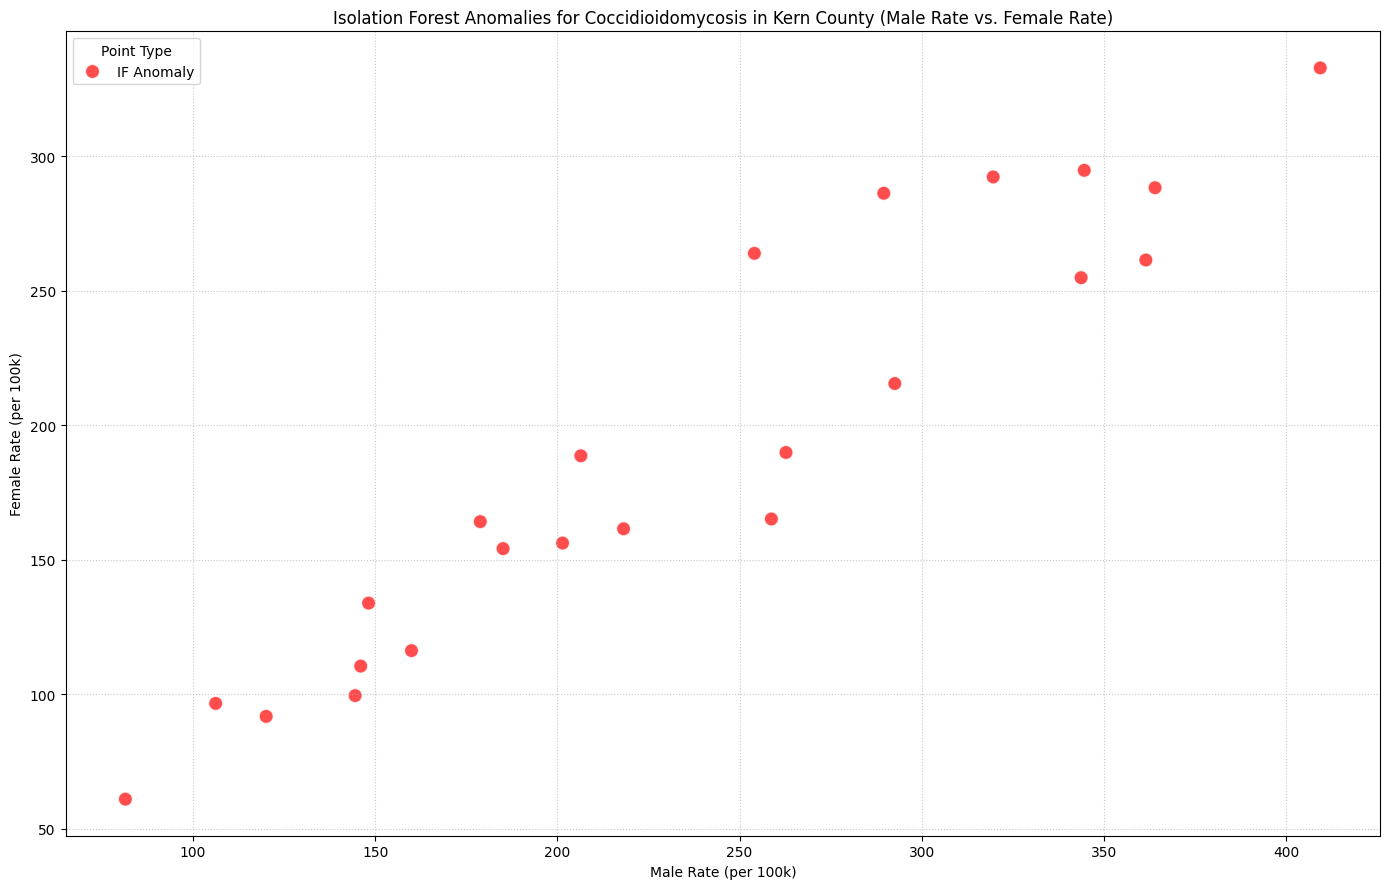

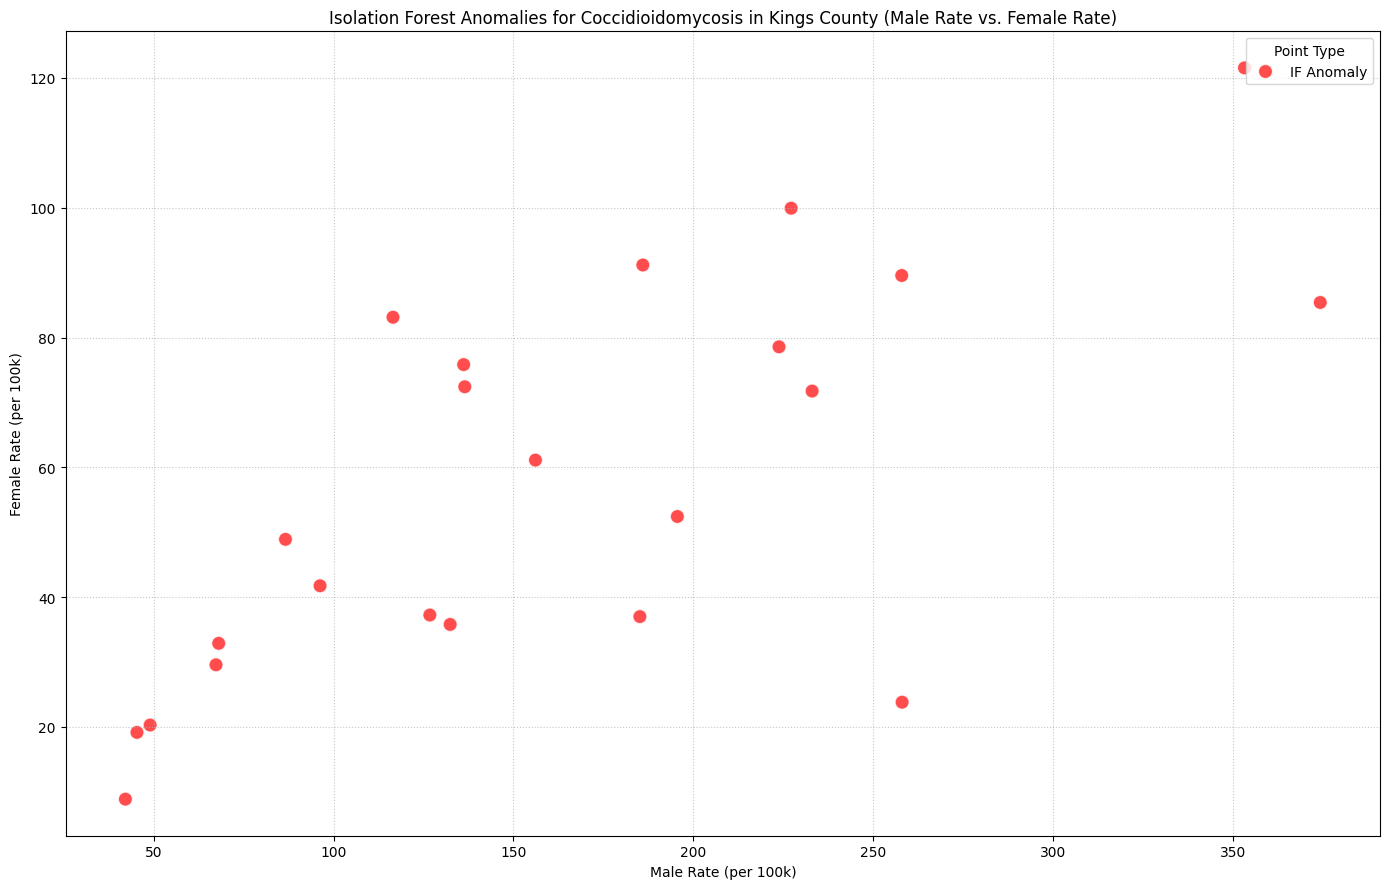

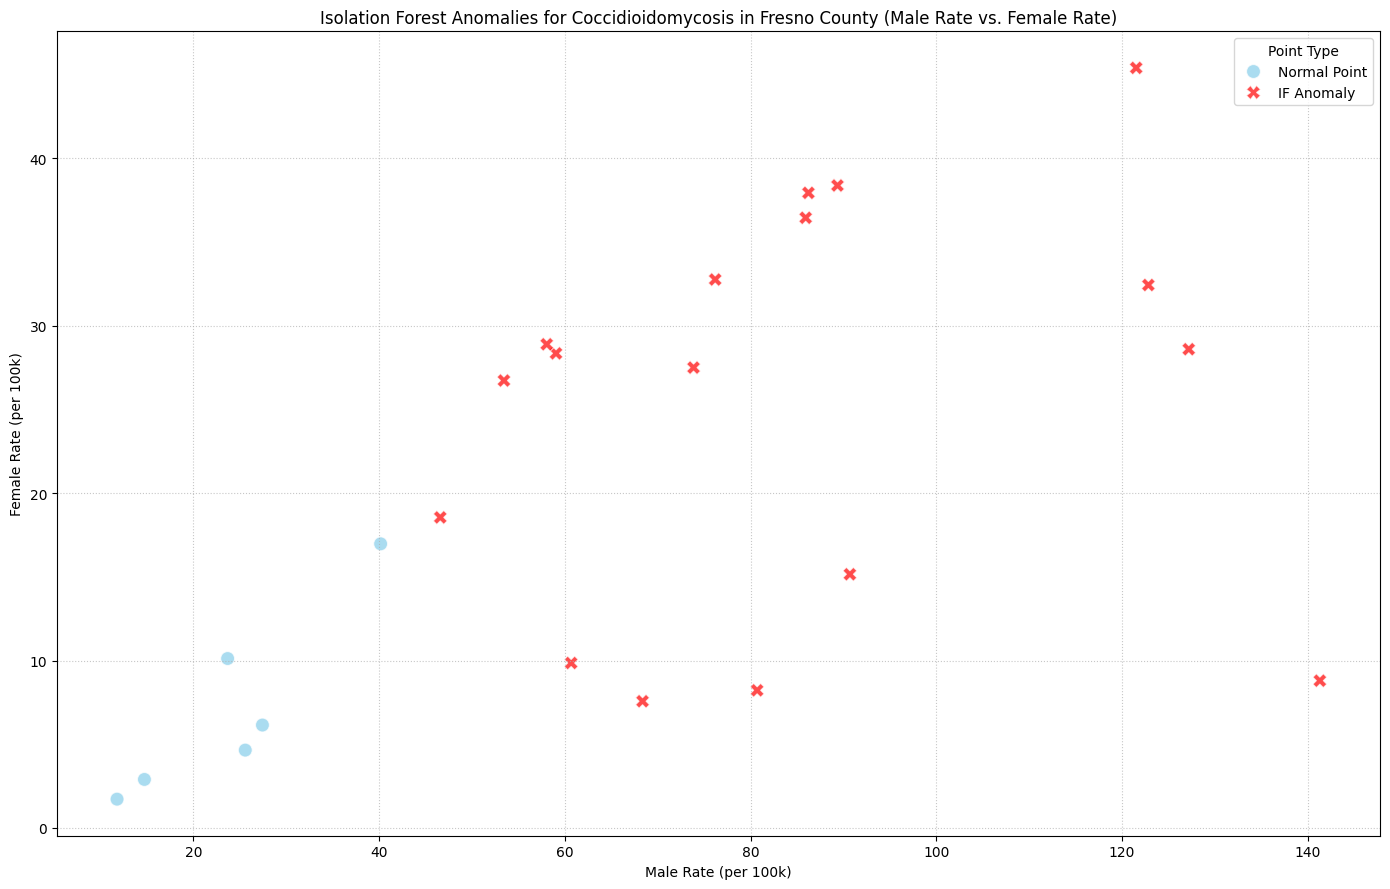

In [19]:
selected_counties = ['Kern', 'Kings', 'Fresno']

for county_name in selected_counties:
    df_cocci_county = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['county'] == county_name)].copy()
    df_cocci_county[['male_rate', 'female_rate']] = df_cocci_county[['male_rate', 'female_rate']].astype(float)

    # Plot for Isolation Forest Anomalies in the current county
    df_cocci_county['is_iforest_anomaly'] = np.where(df_cocci_county['anomaly_iforest'] == -1, 'IF Anomaly', 'Normal Point')

    plt.figure(figsize=(14, 9))
    sns.scatterplot(
        data=df_cocci_county,
        x='male_rate',
        y='female_rate',
        hue='is_iforest_anomaly',
        style='is_iforest_anomaly',
        palette={'IF Anomaly': 'red', 'Normal Point': 'skyblue'},
        s=100,
        alpha=0.7
    )
    plt.title(f'Isolation Forest Anomalies for Coccidioidomycosis in {county_name} County (Male Rate vs. Female Rate)')
    plt.xlabel('Male Rate (per 100k)')
    plt.ylabel('Female Rate (per 100k)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(title='Point Type')
    plt.tight_layout()
    plt.show()

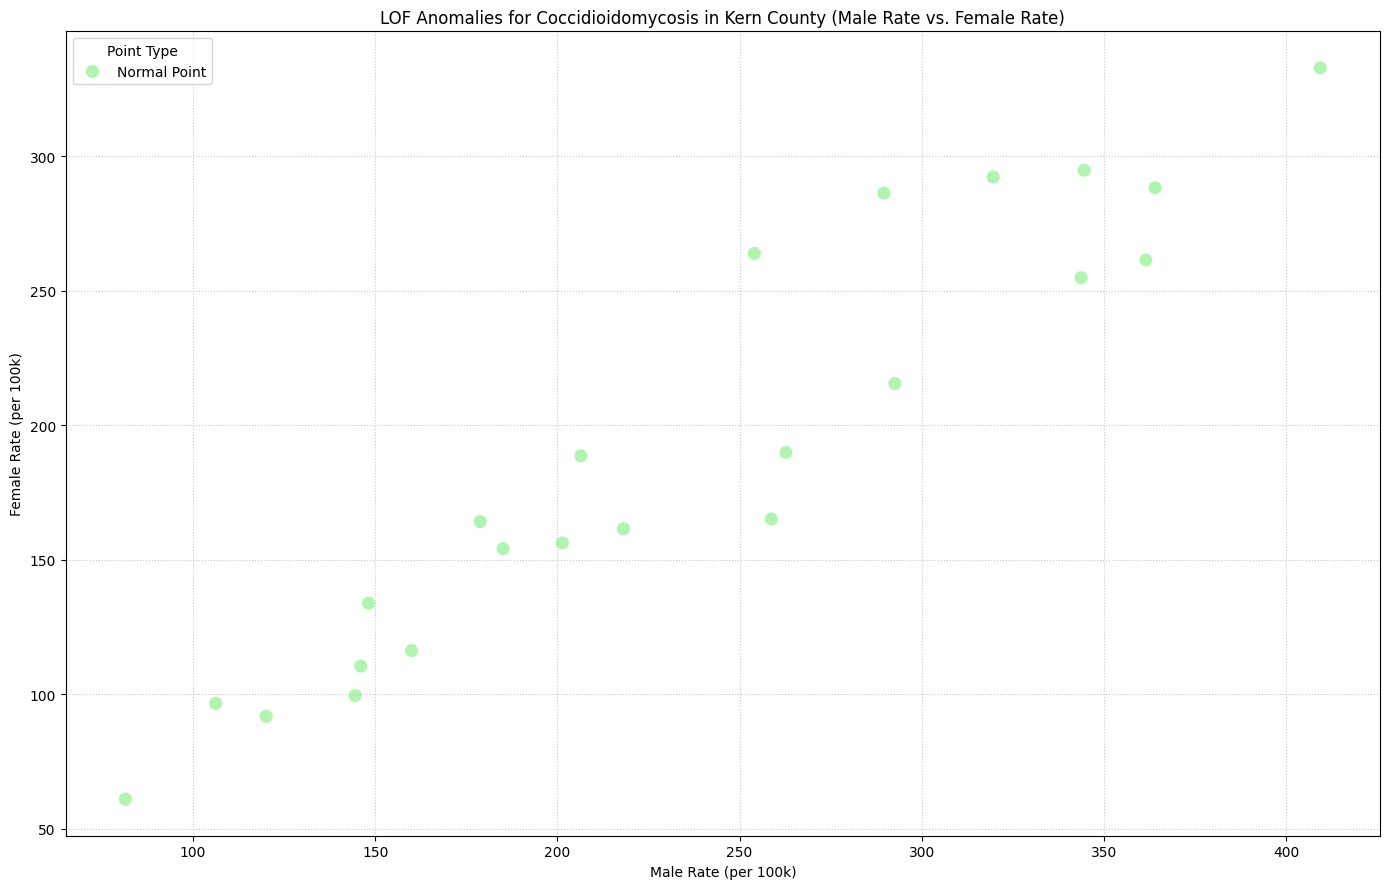

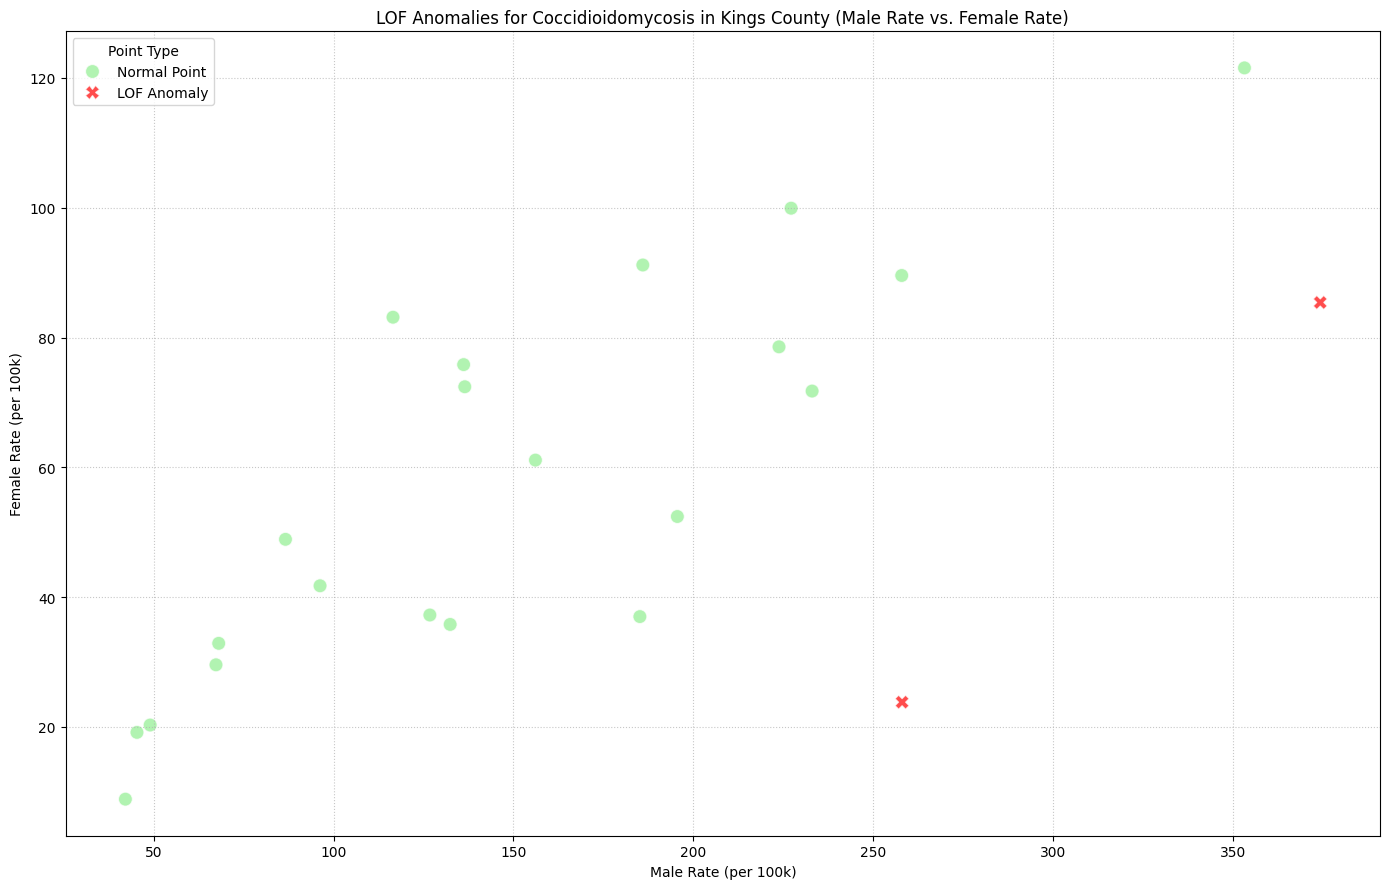

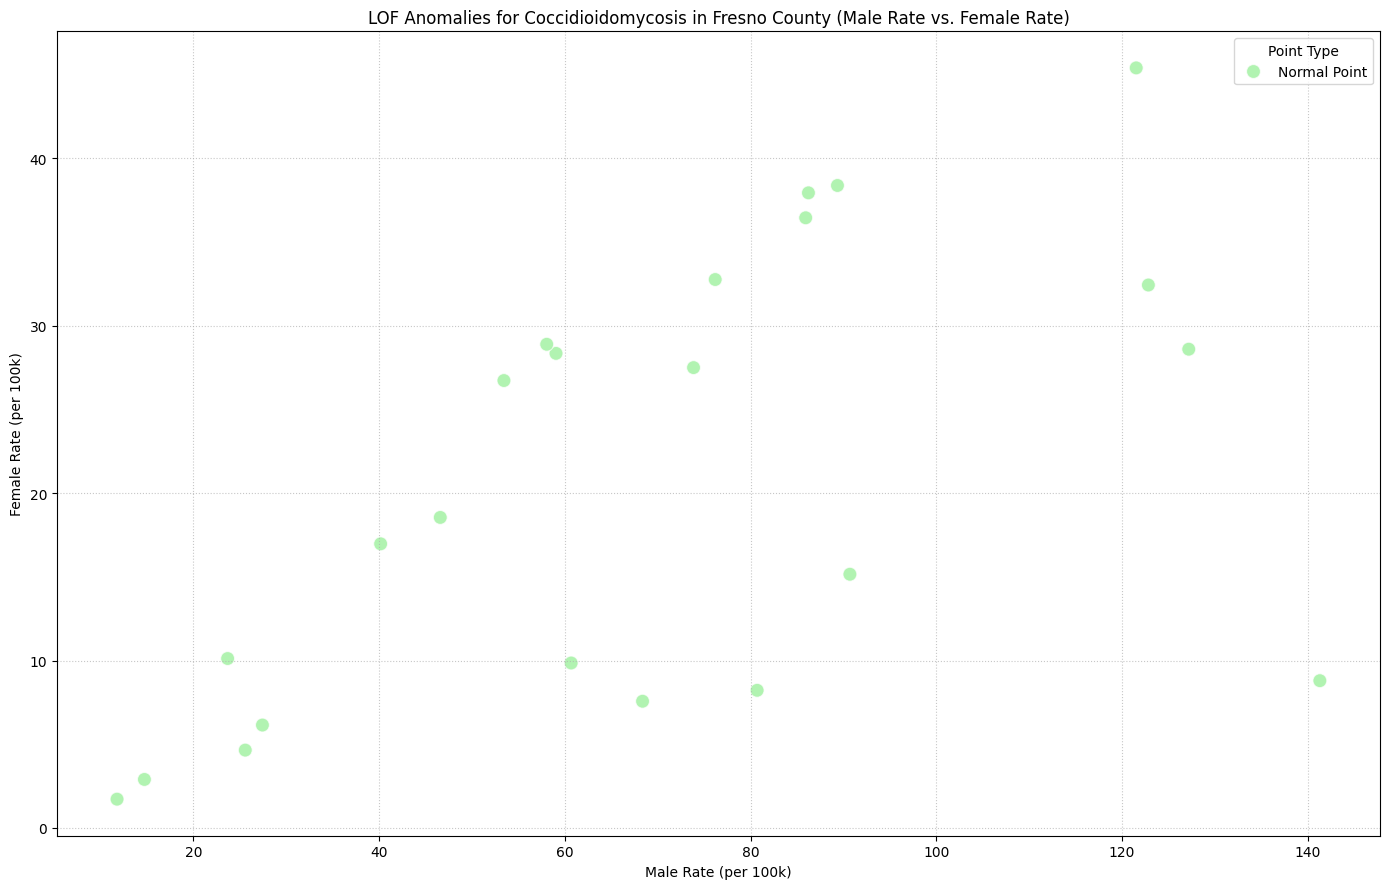

In [20]:
selected_counties = ['Kern', 'Kings', 'Fresno']

for county_name in selected_counties:
    df_cocci_county = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['county'] == county_name)].copy()
    df_cocci_county[['male_rate', 'female_rate']] = df_cocci_county[['male_rate', 'female_rate']].astype(float)

    # Plot for LOF Anomalies in the current county
    df_cocci_county['is_lof_anomaly'] = np.where(df_cocci_county['anomaly_lof'] == -1, 'LOF Anomaly', 'Normal Point')

    plt.figure(figsize=(14, 9))
    sns.scatterplot(
        data=df_cocci_county,
        x='male_rate',
        y='female_rate',
        hue='is_lof_anomaly',
        style='is_lof_anomaly',
        palette={'LOF Anomaly': 'red', 'Normal Point': 'lightgreen'},
        s=100,
        alpha=0.7
    )
    plt.title(f'LOF Anomalies for Coccidioidomycosis in {county_name} County (Male Rate vs. Female Rate)')
    plt.xlabel('Male Rate (per 100k)')
    plt.ylabel('Female Rate (per 100k)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(title='Point Type')
    plt.tight_layout()
    plt.show()

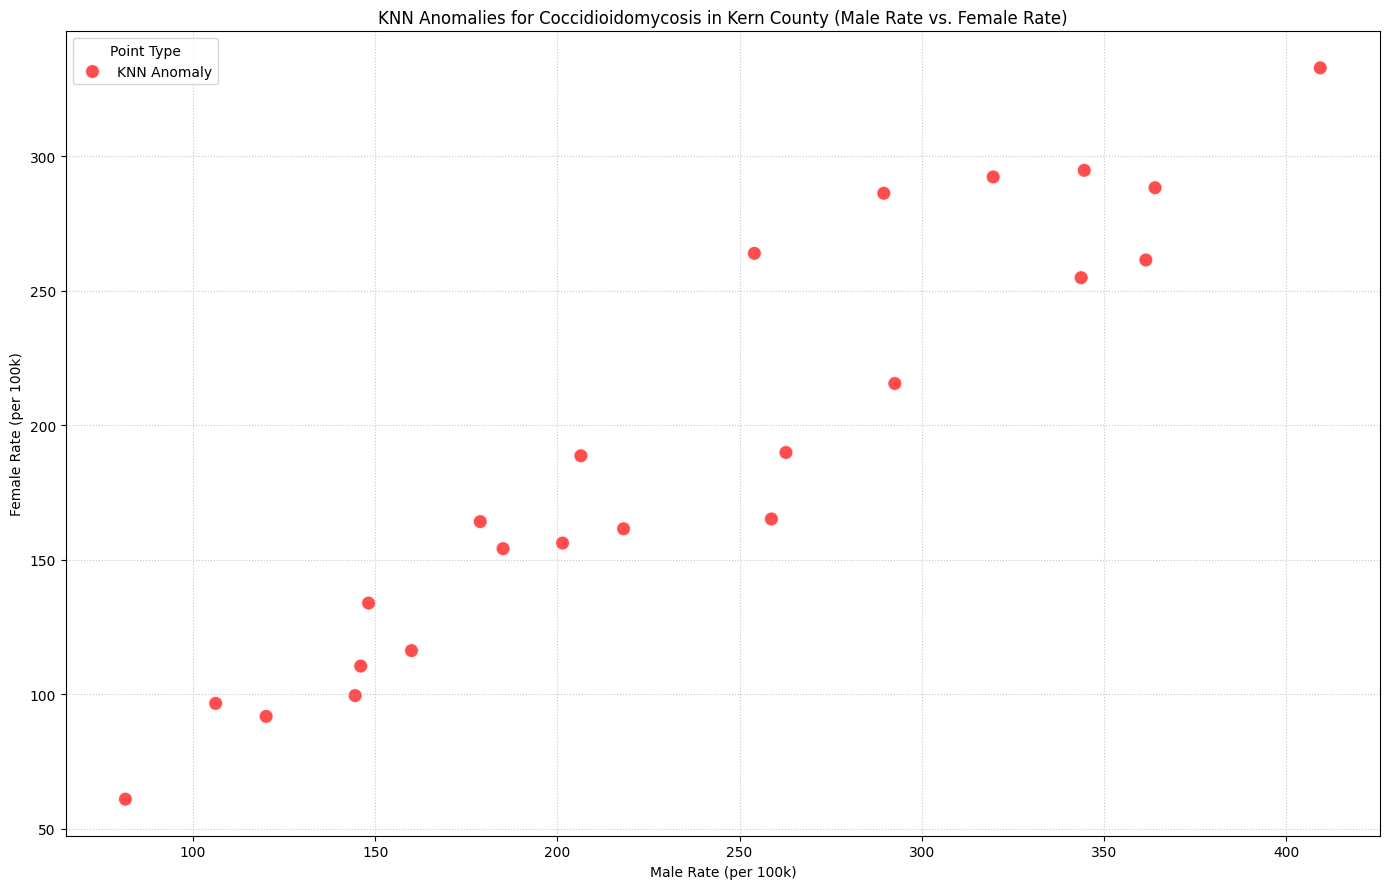

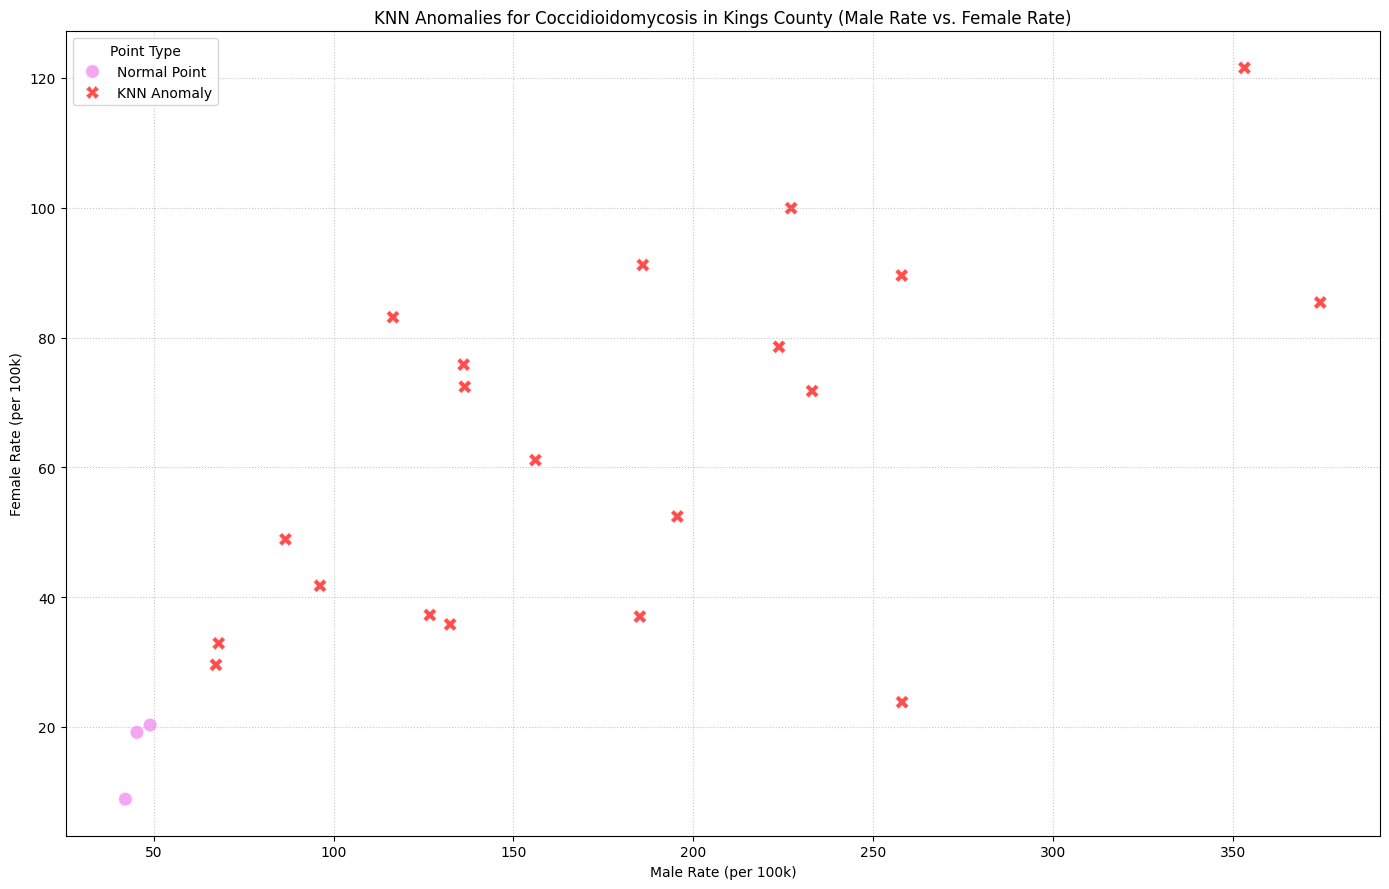

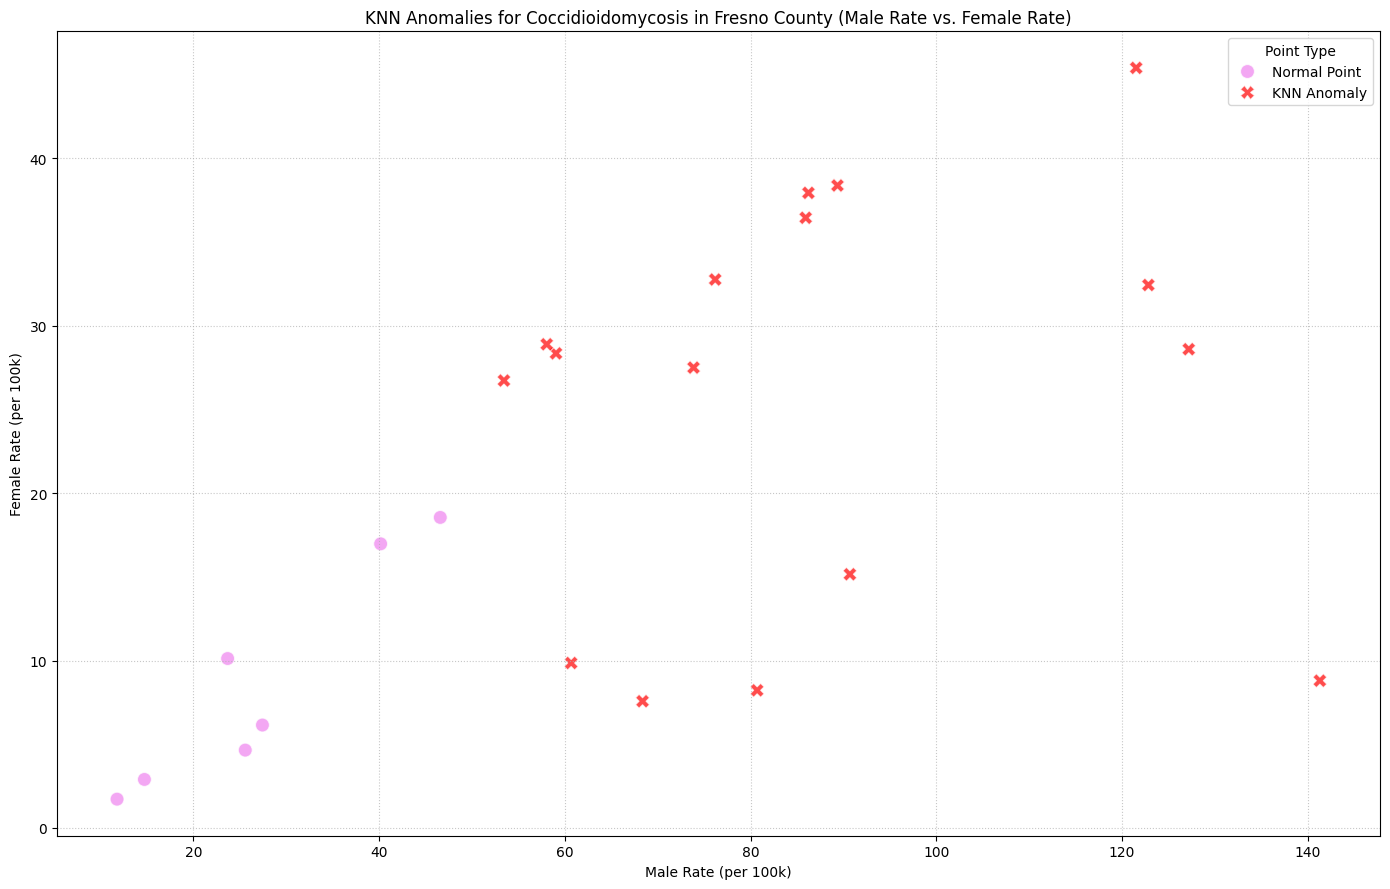

In [21]:
selected_counties = ['Kern', 'Kings', 'Fresno']

for county_name in selected_counties:
    df_cocci_county = df_model[(df_model['disease'] == 'Coccidioidomycosis') & (df_model['county'] == county_name)].copy()
    df_cocci_county[['male_rate', 'female_rate']] = df_cocci_county[['male_rate', 'female_rate']].astype(float)

    # Plot for KNN Anomalies in the current county
    df_cocci_county['is_knn_anomaly'] = np.where(df_cocci_county['anomaly_knn'] == -1, 'KNN Anomaly', 'Normal Point')

    plt.figure(figsize=(14, 9))
    sns.scatterplot(
        data=df_cocci_county,
        x='male_rate',
        y='female_rate',
        hue='is_knn_anomaly',
        style='is_knn_anomaly',
        palette={'KNN Anomaly': 'red', 'Normal Point': 'violet'},
        s=100,
        alpha=0.7
    )
    plt.title(f'KNN Anomalies for Coccidioidomycosis in {county_name} County (Male Rate vs. Female Rate)')
    plt.xlabel('Male Rate (per 100k)')
    plt.ylabel('Female Rate (per 100k)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(title='Point Type')
    plt.tight_layout()
    plt.show()

When observing the Valley Fever cases for Kern, Kings, and Fresno county and the relation between the cases marked as anomalies and the cases that are not, we observe some interesting findings. In Isolation Forest, all of the plotted Valley Fever cases for Kern and Kings county. For KNN, all of the plotted cases are also anomalies. This indicates that Valley Fever transmission rate for Kings county are particularly unique compared to the Valley Fever transmission rates found in the rest of the dataset.

# DBSCAN Clustering

We will now perform DBSCAN clustering on the anomalous data points and highlight the points that are detected across all 3 detection methods and apply PCA. PCA1 captures the magnitude of the variances in the male and female rates, and the rate differnces. PCA2 captures the second highest variance present.

## PCA Visualization

In [47]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Perform PCA
pca = PCA()
pca.fit(X_cleaned)

# Get the principal components
components = pca.components_

# Create a DataFrame for loadings to easily inspect feature contributions
loadings = pd.DataFrame(components.T, columns=[f'PC{i+1}' for i in range(components.shape[0])], index=X_cleaned.columns)

print("Principal Component Loadings for PC1:")
display(loadings['PC1'].sort_values(ascending=False))

# Transform the data using the fitted PCA model
X_pca = pca.transform(X_cleaned)

# Create a DataFrame for the PCA components
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])], index=X_cleaned.index)

# Add anomaly labels for LOF and KNN to the PCA DataFrame
df_pca['anomaly_iforest'] = df_model.loc[X_cleaned.index, 'anomaly_iforest']
df_pca['anomaly_lof'] = df_model.loc[X_cleaned.index, 'anomaly_lof']
df_pca['anomaly_knn'] = df_model.loc[X_cleaned.index, 'anomaly_knn']
df_pca['anomaly_all_three'] = df_model.loc[X_cleaned.index, 'anomaly_all_three']
# Add disease column for filtering in subsequent steps
df_pca['disease'] = df_model.loc[X_cleaned.index, 'disease']

# # Filter for Coccidioidomycosis cases for plotting
# df_pca_cocci = df_pca[df_pca['disease'] == 'Coccidioidomycosis'].copy()

# # Plot for Isolation Forest Anomalies (Coccidioidomycosis only)
# plt.figure(figsize=(12, 8))
# sns.scatterplot(
#     x='PC1',
#     y='PC2',
#     hue='anomaly_iforest',
#     palette={1: 'skyblue', -1: 'red'},
#     style='anomaly_iforest',
#     markers={1: 'o', -1: 'X'},
#     s=100,
#     alpha=0.7,
#     data=df_pca_cocci # Use filtered data
# )
# # Highlight 'all three' anomalies
# all_three_cocci_anomalies = df_pca_cocci[df_pca_cocci['anomaly_all_three'] == 1]
# if not all_three_cocci_anomalies.empty:
#     sns.scatterplot(
#         x='PC1',
#         y='PC2',
#         data=all_three_cocci_anomalies,
#         color='red',
#         marker='o',
#         s=400, # Larger size to make the circle prominent
#         facecolors='none',
#         edgecolors='red',
#         linewidth=2,
#         label='Anomaly in All Three Methods'
#     )
# plt.title('PCA Scatter Plot of Coccidioidomycosis with Isolation Forest Anomalies')
# plt.xlabel('Principal Component 1 (PC1)')
# plt.ylabel('Principal Component 2 (PC2)')
# plt.grid(True, linestyle=':', alpha=0.7)
# plt.legend(title='Anomaly Status')
# plt.tight_layout()
# plt.show()

# # Plot for LOF Anomalies (Coccidioidomycosis only)
# plt.figure(figsize=(12, 8))
# sns.scatterplot(
#     x='PC1',
#     y='PC2',
#     hue='anomaly_lof',
#     palette={1: 'lightgreen', -1: 'red'},
#     style='anomaly_lof',
#     markers={1: 'o', -1: 'X'},
#     s=100,
#     alpha=0.7,
#     data=df_pca_cocci # Use filtered data
# )
# # Highlight 'all three' anomalies
# if not all_three_cocci_anomalies.empty:
#     sns.scatterplot(
#         x='PC1',
#         y='PC2',
#         data=all_three_cocci_anomalies,
#         color='red',
#         marker='o',
#         s=400, # Larger size to make the circle prominent
#         facecolors='none',
#         edgecolors='red',
#         linewidth=2,
#         label='Anomaly in All Three Methods'
#     )
# plt.title('PCA Scatter Plot of Coccidioidomycosis with LOF Anomalies')
# plt.xlabel('Principal Component 1 (PC1)')
# plt.ylabel('Principal Component 2 (PC2)')
# plt.grid(True, linestyle=':', alpha=0.7)
# plt.legend(title='Anomaly Status')
# plt.tight_layout()
# plt.show()

# # Plot for KNN Anomalies (Coccidioidomycosis only)
# plt.figure(figsize=(12, 8))
# sns.scatterplot(
#     x='PC1',
#     y='PC2',
#     hue='anomaly_knn',
#     palette={1: 'violet', -1: 'red'},
#     style='anomaly_knn',
#     markers={1: 'o', -1: 'X'},
#     s=100,
#     alpha=0.7,
#     data=df_pca_cocci # Use filtered data
# )
# # Highlight 'all three' anomalies
# if not all_three_cocci_anomalies.empty:
#     sns.scatterplot(
#         x='PC1',
#         y='PC2',
#         data=all_three_cocci_anomalies,
#         color='red',
#         marker='o',
#         s=400, # Larger size to make the circle prominent
#         facecolors='none',
#         edgecolors='red',
#         linewidth=2,
#         label='Anomaly in All Three Methods'
#     )
# plt.title('PCA Scatter Plot of Coccidioidomycosis with KNN Anomalies')
# plt.xlabel('Principal Component 1 (PC1)')
# plt.ylabel('Principal Component 2 (PC2)')
# plt.grid(True, linestyle=':', alpha=0.7)
# plt.legend(title='Anomaly Status')
# plt.tight_layout()
# plt.show()

Principal Component Loadings for PC1:


,PC1
male_rate,0.771293
female_rate,0.506629
abs_rate_diff,0.277271
rate_diff,0.264664
log_total_cases,0.038126
log_rate_ratio,-0.002582
log_total_population,-0.006876


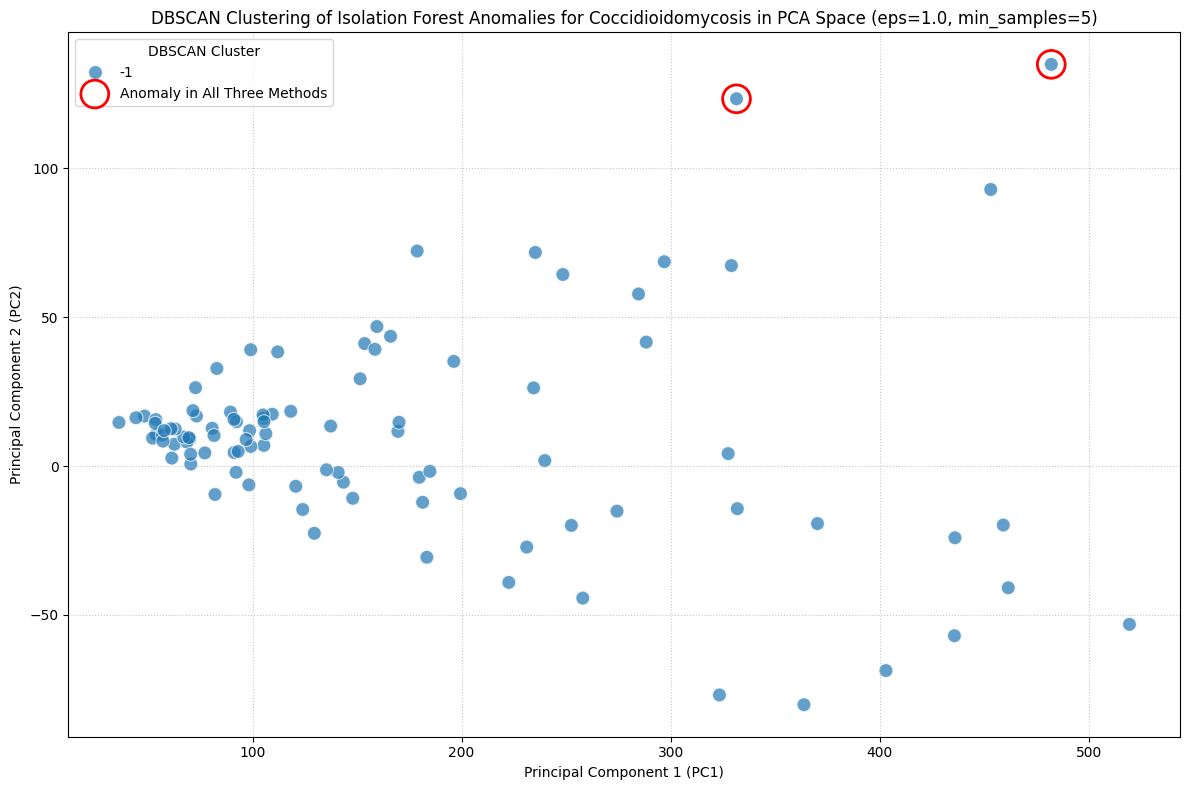

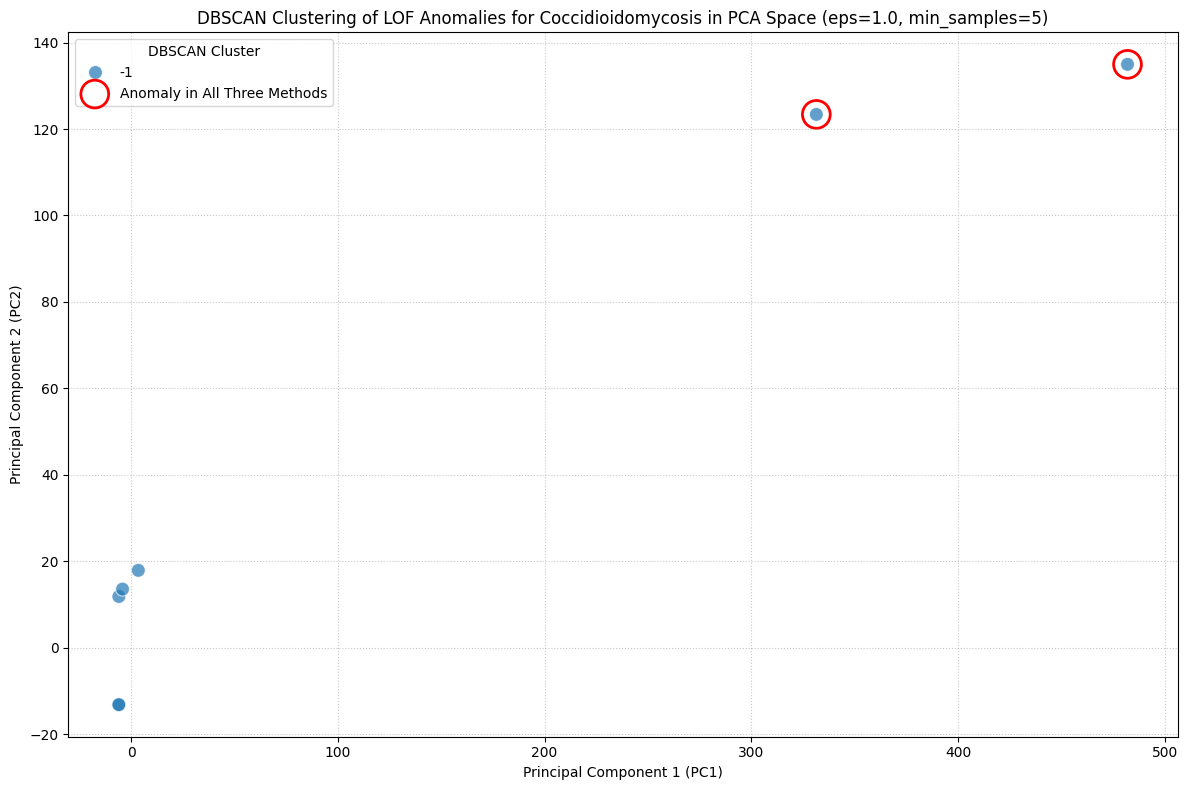

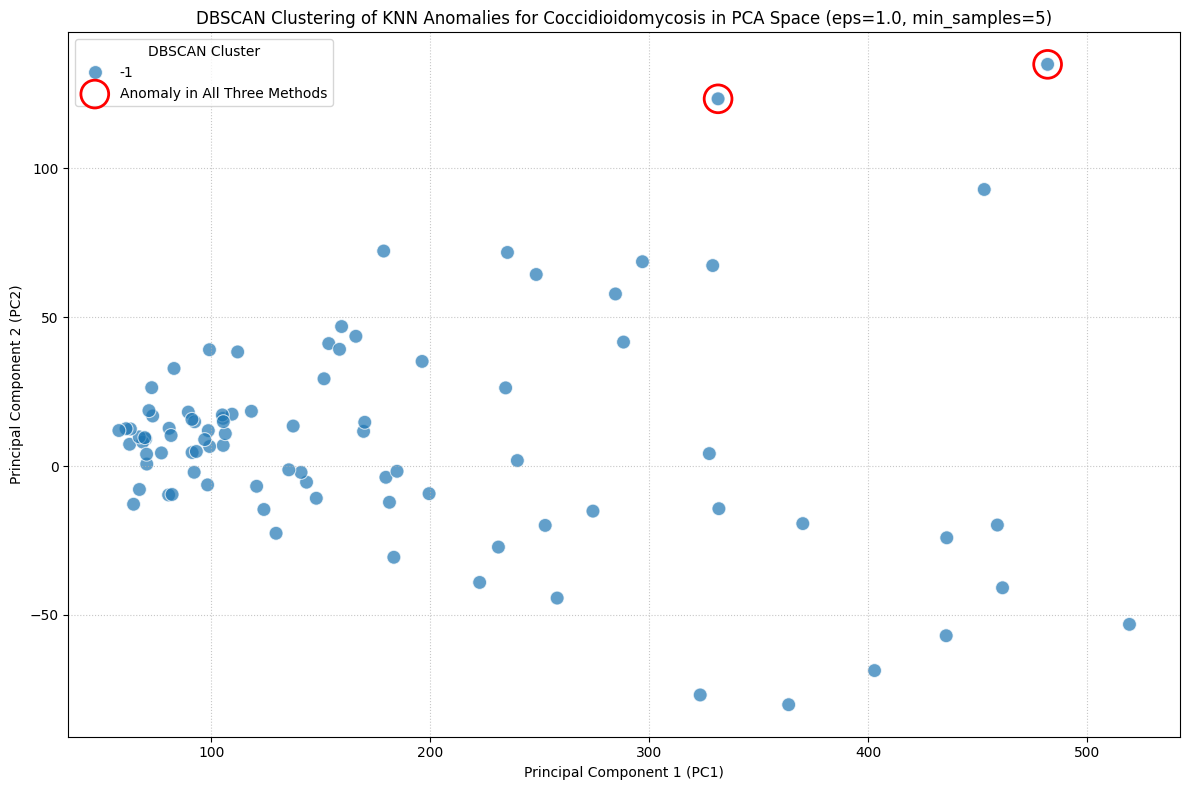


Note: DBSCAN results are sensitive to 'eps' and 'min_samples'. You might need to tune these parameters for optimal clustering.


In [48]:
from sklearn.cluster import DBSCAN

# DBSCAN parameters (can be tuned)
DBSCAN_EPS = 1.0 # The maximum distance between two samples for one to be considered as in the neighborhood of the other
DBSCAN_MIN_SAMPLES = 5 # The number of samples (or total weight) in a neighborhood for a point to be considered as a core point

# Filter df_pca for Coccidioidomycosis cases
df_pca_cocci = df_pca[df_pca['disease'] == 'Coccidioidomycosis'].copy()

# Define anomaly columns and titles for iteration for DBSCAN visualization
anomaly_methods_dbscan = {
    'Isolation Forest': 'anomaly_iforest',
    'LOF': 'anomaly_lof',
    'KNN': 'anomaly_knn'
}

for method_name, anomaly_col in anomaly_methods_dbscan.items():
    # Filter for anomalies of the current method from the Coccidioidomycosis-specific DataFrame
    # Note: anomaly_iforest, anomaly_lof, anomaly_knn are -1 for anomaly, 1 for normal
    df_anomalies_pca = df_pca_cocci[df_pca_cocci[anomaly_col] == -1].copy()

    if not df_anomalies_pca.empty:
        # Perform DBSCAN clustering on the PC1 and PC2 of these anomalies
        dbscan = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
        clusters = dbscan.fit_predict(df_anomalies_pca[['PC1', 'PC2']])
        df_anomalies_pca['dbscan_cluster'] = clusters

        plt.figure(figsize=(12, 8))
        sns.scatterplot(
            x='PC1',
            y='PC2',
            hue='dbscan_cluster',
            palette='tab10', # Using a distinct palette for clusters
            s=100,
            alpha=0.7,
            data=df_anomalies_pca
        )

        # Highlight points that are anomalies in ALL THREE methods (cocci-specific)
        all_three_overlap_anomalies = df_anomalies_pca[df_anomalies_pca['anomaly_all_three'] == 1]
        if not all_three_overlap_anomalies.empty:
            sns.scatterplot(
                x='PC1',
                y='PC2',
                data=all_three_overlap_anomalies,
                color='red', # Highlight color for overlap
                marker='o',
                s=400, # Larger size to make the circle prominent
                facecolors='none', # No fill
                edgecolors='red', # Red circle edge
                linewidth=2, # Make the circle line thicker
                label='Anomaly in All Three Methods'
            )
            # Adjust legend to include the 'Anomaly in All Three Methods' entry properly
            handles, labels = plt.gca().get_legend_handles_labels()
            unique_labels = list(dict.fromkeys(labels)) # Preserve order, remove duplicates
            unique_handles = []
            for label in unique_labels:
                for i, l in enumerate(labels):
                    if l == label:
                        unique_handles.append(handles[i])
                        break
            plt.legend(unique_handles, unique_labels, title='DBSCAN Cluster')
        else:
            plt.legend(title='DBSCAN Cluster') # Only show DBSCAN legend if no overlap points


        plt.title(f'DBSCAN Clustering of {method_name} Anomalies for Coccidioidomycosis in PCA Space (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})')
        plt.xlabel('Principal Component 1 (PC1)')
        plt.ylabel('Principal Component 2 (PC2)')
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No {method_name} anomalies for Coccidioidomycosis to cluster.")

print("\nNote: DBSCAN results are sensitive to 'eps' and 'min_samples'. You might need to tune these parameters for optimal clustering.")


In [38]:
# Filter the previously identified isolated Isolation Forest anomalies (from isolated_top_right_if)
specific_isolated_anomalies = isolated_top_right_if[
    (isolated_top_right_if['PC1'] >= 300) &
    (isolated_top_right_if['PC1'] <= 500) &
    (isolated_top_right_if['PC2'] > 100)
].copy()

# Get the original disease, county, year information for these specific points
specific_isolated_details = df_model.loc[specific_isolated_anomalies.index, identifier_cols].merge(
    specific_isolated_anomalies[['PC1', 'PC2', 'dbscan_cluster']],
    left_index=True,
    right_index=True
)

print("Isolated Isolation Forest anomalies with PC1 between 300-500 and PC2 > 100:")
display(specific_isolated_details)


Isolated Isolation Forest anomalies with PC1 between 300-500 and PC2 > 100:


,disease,county,year,PC1,PC2,dbscan_cluster
14154,Coccidioidomycosis,Kings,2006,331.466628,123.376581,-1
14159,Coccidioidomycosis,Kings,2011,481.988063,134.956706,-1


In all three plots, the overlapping anomaly points are all in upper top right quandrant and are highly seperated from the rest of the points in the cluster. This indicates that these cases that there is an extreme regarding male and female transmission rates with a particular extreme skewing towards a high infection rate in men. It's identified that these two cases for Kings County in 2011 and Kings County in 2006.  

# Future Scope
Question: What is the result of the extreme male infection rate in Kings county in 2006 and 2011?

To further explore this question, we need further data that is currently not in the scope of this project. Valley Fever is a fungal disease that occurs when there are disruptions in the soil so some further information we need would be wind indicies and any information that indicates the presence of drought. As for the explanation of men being predominantly targted, we need to know the presence fields such as agriculture and construction in this county and teh gender demographics for this field. Additionally, Kings county is home to a large number of overcrowded prison facilities that are hotbeds for disease so the demographics of these institutions would be needed as well.